In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection

P1

Solución analítica

In [2]:
def solucion_analitica(z, P, a_0, E, L):

    tension = (P / a_0) * np.exp(z / L)

    desplazamiento = (P * L / (E * a_0)) * (np.exp(z / L) - 1)

    return desplazamiento, tension


a_0 = 1600      
L = 10000       
E = 206000      
P = 3000       

z = np.linspace(0, L, 100)

w_analitico, sigma_analitico = solucion_analitica(z, P, a_0, E, L)

print(w_analitico)
print(sigma_analitico)

print("Desplazamiento máximo:", w_analitico[-1], "mm")
print("Tensión máxima:", sigma_analitico[-1], "MPa")

[0.         0.00092405 0.00185748 0.00280038 0.00375286 0.004715
 0.00568692 0.0066687  0.00766045 0.00866227 0.00967426 0.01069652
 0.01172916 0.01277228 0.013826   0.01489041 0.01596562 0.01705176
 0.01814892 0.01925722 0.02037677 0.02150768 0.02265008 0.02380407
 0.02496979 0.02614733 0.02733683 0.02853841 0.02975218 0.03097828
 0.03221682 0.03346794 0.03473176 0.03600841 0.03729802 0.03860073
 0.03991666 0.04124595 0.04258873 0.04394515 0.04531533 0.04669943
 0.04809758 0.04950992 0.0509366  0.05237777 0.05383357 0.05530414
 0.05678965 0.05829024 0.05980606 0.06133727 0.06288402 0.06444648
 0.0660248  0.06761914 0.06922967 0.07085655 0.07249995 0.07416003
 0.07583697 0.07753093 0.07924208 0.08097061 0.08271669 0.08448049
 0.0862622  0.088062   0.08988007 0.0917166  0.09357177 0.09544577
 0.09733881 0.09925106 0.10118272 0.10313399 0.10510508 0.10709617
 0.10910748 0.11113921 0.11319156 0.11526475 0.11735899 0.11947449
 0.12161146 0.12377013 0.12595072 0.12815344 0.13037853 0.132626

In [3]:
def centros_nodos(nodos, L):
  z_nodos = np.linspace(0, L, nodos)

  zc_nodos = np.zeros(nodos)
  for i in range(len(zc_nodos)):
    if i == 0:
      zc_nodos[i] = 0
    else:
      zc_nodos[i] = (z_nodos[i] - z_nodos[i-1]) / 2 + z_nodos[i-1]

  return zc_nodos

def calcular_vector_k(elementos, L, E, area_nodo):
  vector_k = np.zeros(elementos)
  for i in range(len(vector_k)):
    vector_k[i] = E * area_nodo[i + 1] / (L/elementos)
  return vector_k

def matriz_k(vector_k, nodos):
  K = np.zeros((nodos, nodos))
  for i in range(nodos - 1):
    Ki = vector_k[i] * np.array([[1, -1],[-1, 1]])
    K[i:i+2, i:i+2] += Ki
  return K

def resolver_sistema(K, nodos, P):
  F = np.zeros(nodos)
  F[-1] = P
  Kr = K[1:, 1:]
  Fr = F[1:]
  Ur = np.linalg.solve(Kr, Fr)
  U = np.zeros(nodos)
  U[1:] = Ur
  return U

def calcular_deformaciones(U, elementos, L):

    Le = L / elementos

    deformaciones = np.zeros(elementos)

    for i in range(elementos):

        deformaciones[i] = (U[i + 1] - U[i]) / Le

    return deformaciones

def calcular_tensiones(deformaciones, E):

    tensiones = E * deformaciones

    return tensiones

Para 1 Elemento

In [4]:
elementos = 1
nodos = elementos + 1
a_0 = 1600
L = 10000
E = 206000
P = 3000

zc_nodos = centros_nodos(nodos, L)

area_nodo = a_0 * np.exp(- zc_nodos/ L)

vector_k = calcular_vector_k(elementos, L, E, area_nodo)

K = matriz_k(vector_k, nodos)

resolucion_1 = resolver_sistema(K, nodos, P)
print(resolucion_1)

deformaciones_1 = calcular_deformaciones(resolucion_1, elementos, L)
print(deformaciones_1)

tensiones_1 = calcular_tensiones(deformaciones_1, E)
print(tensiones_1)


[0.         0.15006565]
[1.5006565e-05]
[3.09135238]


Para 2 elementos

In [5]:
elementos = 2
nodos = elementos + 1
a_0 = 1600
L = 10000
E = 206000
P = 3000

zc_nodos = centros_nodos(nodos, L)

area_nodo = a_0 * np.exp(- zc_nodos/ L)

vector_k = calcular_vector_k(elementos, L, E, area_nodo)

K = matriz_k(vector_k, nodos)

resolucion_2 = resolver_sistema(K, nodos, P)
print(resolucion_2)

deformaciones_2 = calcular_deformaciones(resolucion_2, elementos, L)
print(deformaciones_2)

tensiones_2 = calcular_tensiones(deformaciones_2, E)
print(tensiones_2)


[0.         0.05843562 0.15477968]
[1.16871245e-05 1.92688108e-05]
[2.40754766 3.96937503]


Para 4 elementos

In [6]:
elementos = 4
nodos = elementos + 1
a_0 = 1600
L = 10000
E = 206000
P = 3000

zc_nodos = centros_nodos(nodos, L)

area_nodo = a_0 * np.exp(- zc_nodos/ L)

vector_k = calcular_vector_k(elementos, L, E, area_nodo)

K = matriz_k(vector_k, nodos)

resolucion_4 = resolver_sistema(K, nodos, P)
print(resolucion_4)

deformaciones_4 = calcular_deformaciones(resolucion_4, elementos, L)
print(deformaciones_4)

tensiones_4 = calcular_tensiones(deformaciones_4, E)
print(tensiones_4)


[0.         0.02578463 0.05889275 0.10140441 0.15599047]
[1.03138512e-05 1.32432471e-05 1.70046659e-05 2.18344232e-05]
[2.12465335 2.7281089  3.50296117 4.49789118]


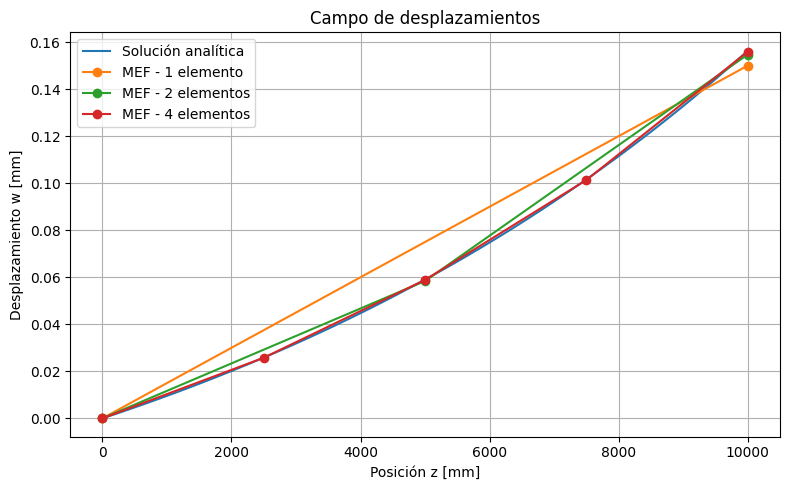

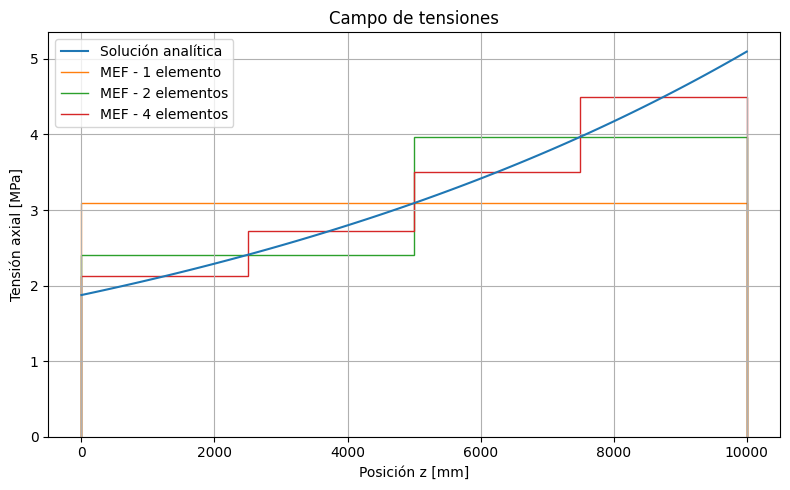

In [7]:
z_nodos_1 = np.linspace(0, L, 2)
z_nodos_2 = np.linspace(0, L, 3)
z_nodos_4 = np.linspace(0, L, 5)


plt.figure(figsize=(8, 5))

plt.plot(
    z,
    w_analitico,
    label="Solución analítica"
)

# Soluciones MEF
plt.plot(
    z_nodos_1,
    resolucion_1,
    marker="o",
    label="MEF - 1 elemento"
)

plt.plot(
    z_nodos_2,
    resolucion_2,
    marker="o",
    label="MEF - 2 elementos"
)

plt.plot(
    z_nodos_4,
    resolucion_4,
    marker="o",
    label="MEF - 4 elementos"
)

plt.xlabel("Posición z [mm]")
plt.ylabel("Desplazamiento w [mm]")
plt.title("Campo de desplazamientos")
plt.grid()
plt.legend()
plt.tight_layout()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    z,
    sigma_analitico,
    label="Solución analítica"
)

plt.stairs(
    tensiones_1,
    z_nodos_1,
    label="MEF - 1 elemento"
)

plt.stairs(
    tensiones_2,
    z_nodos_2,
    label="MEF - 2 elementos"
)

plt.stairs(
    tensiones_4,
    z_nodos_4,
    label="MEF - 4 elementos"
)

plt.xlabel("Posición z [mm]")
plt.ylabel("Tensión axial [MPa]")
plt.title("Campo de tensiones")
plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

In [8]:
w_exacto = w_analitico[-1]

error_1 = abs((resolucion_1[-1] - w_exacto) / w_exacto) * 100
error_2 = abs((resolucion_2[-1] - w_exacto) / w_exacto) * 100
error_4 = abs((resolucion_4[-1] - w_exacto) / w_exacto) * 100

tabla_error = pd.DataFrame({
    "Elementos": [1, 2, 4],
    "Desplazamiento MEF [mm]": [
        resolucion_1[-1],
        resolucion_2[-1],
        resolucion_4[-1]
    ],
    "Desplazamiento analítico [mm]": [
        w_exacto,
        w_exacto,
        w_exacto
    ],
    "Error [%]": [error_1,error_2,error_4]})

tabla_error

,Elementos,Desplazamiento MEF [mm],Desplazamiento analítico [mm],Error [%]
0,1,0.150066,0.156397,4.048262
1,2,0.154780,0.156397,1.034121
2,4,0.155990,0.156397,0.259943


P2

In [9]:
def geometria_elementos(coordenadas, conectividad):

    elementos = len(conectividad)

    longitudes = np.zeros(elementos)
    cosenos = np.zeros(elementos)
    senos = np.zeros(elementos)

    for i in range(elementos):

        nodo_1 = conectividad[i][0]
        nodo_2 = conectividad[i][1]

        x1 = coordenadas[nodo_1][0]
        y1 = coordenadas[nodo_1][1]

        x2 = coordenadas[nodo_2][0]
        y2 = coordenadas[nodo_2][1]

        dx = x2 - x1
        dy = y2 - y1

        Le = np.sqrt(dx**2 + dy**2)

        longitudes[i] = Le
        cosenos[i] = dx / Le
        senos[i] = dy / Le

    return longitudes, cosenos, senos

def matriz_k(coordenadas, conectividad, E, A):

    nodos = len(coordenadas)
    elementos = len(conectividad)

    K = np.zeros((2*nodos, 2*nodos))

    longitudes, cosenos, senos = geometria_elementos(
        coordenadas,
        conectividad
    )

    for i in range(elementos):

        Le = longitudes[i]
        c = cosenos[i]
        s = senos[i]

        Ki = (E * A / Le) * np.array([
            [ c**2,  c*s,   -c**2, -c*s],
            [ c*s,   s**2,  -c*s,  -s**2],
            [-c**2, -c*s,    c**2,  c*s],
            [-c*s,  -s**2,   c*s,   s**2]
        ])

        nodo_1 = conectividad[i][0]
        nodo_2 = conectividad[i][1]

        grados = [2*nodo_1,2*nodo_1 + 1,2*nodo_2,2*nodo_2 + 1]

        for j in range(4):
            for k in range(4):

                K[grados[j], grados[k]] += Ki[j, k]

    return K

def resolver_sistema(K, F, restringidos):

    grados_totales = len(F)

    libres = []

    for i in range(grados_totales):

        if i not in restringidos:

            libres.append(i)

    Kr = K[np.ix_(libres, libres)]

    Fr = F[libres]

    Ur = np.linalg.solve(Kr, Fr)

    U = np.zeros(grados_totales)

    U[libres] = Ur

    return U

def calcular_deformaciones(U, coordenadas, conectividad):

    elementos = len(conectividad)

    deformaciones = np.zeros(elementos)

    longitudes, cosenos, senos = geometria_elementos(
        coordenadas,
        conectividad
    )

    for i in range(elementos):

        nodo_1 = conectividad[i][0]
        nodo_2 = conectividad[i][1]

        Le = longitudes[i]
        c = cosenos[i]
        s = senos[i]

        u1 = U[2*nodo_1]
        v1 = U[2*nodo_1 + 1]

        u2 = U[2*nodo_2]
        v2 = U[2*nodo_2 + 1]

        deformaciones[i] = (
            c*(u2-u1) + s*(v2-v1)
        ) / Le

    return deformaciones

def vector_fuerzas(nodos, nodo_carga, P):

    F = np.zeros(2*nodos)

    F[2*nodo_carga + 1] = -P

    return F


Primer caso

In [10]:
E = 206000     
A = 1000        
P = 50000       

coordenadas = np.array([
    [0,     0],       
    [5000,  0],     
    [10000, 0],   
    [15000, 0],      
    [20000, 0],      

    [2500,  4000],   
    [7500,  4000],   
    [12500, 4000],   
    [17500, 4000]     
])

nodos = len(coordenadas)

conectividad = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],

    [5, 6],
    [6, 7],
    [7, 8],

    [0, 5],
    [5, 1],

    [1, 6],
    [6, 2],

    [2, 7],
    [7, 3],

    [3, 8],
    [8, 4]
])


longitudes, cosenos, senos = geometria_elementos(coordenadas,conectividad)

print("Longitudes de las barras [mm]:")
print(longitudes)

print("\nLongitud máxima [mm]:")
print(np.max(longitudes))

K = matriz_k(coordenadas,conectividad,E,A)

print("\nMatriz global K:")
print(K)

F = vector_fuerzas(nodos,2,P)

print("\nVector de fuerzas:")
print(F)

restringidos = [0, 1, 9]

U = resolver_sistema(K,F,restringidos)

print("\nVector de desplazamientos [mm]:")
print(U)

deformaciones = calcular_deformaciones(U,coordenadas,conectividad)

print("\nDeformaciones:")
print(deformaciones)

tensiones = calcular_tensiones(deformaciones,E)

reacciones = K @ U - F

desplazamientos_verticales = U[1::2]

desplazamiento_maximo = np.max(np.abs(desplazamientos_verticales))

tension_maxima = np.max(np.abs(tensiones))

print("Desplazamiento vertical máximo:",desplazamiento_maximo,"mm")

print("Tensión máxima:",tension_maxima,"MPa")


Longitudes de las barras [mm]:
[5000.         5000.         5000.         5000.         5000.
 5000.         5000.         4716.99056603 4716.99056603 4716.99056603
 4716.99056603 4716.99056603 4716.99056603 4716.99056603 4716.99056603]

Longitud máxima [mm]:
5000.0

Matriz global K:
[[ 53467.39119558  19627.82591293 -41200.              0.
       0.              0.              0.              0.
       0.              0.         -12267.39119558 -19627.82591293
       0.              0.              0.              0.
       0.              0.        ]
 [ 19627.82591293  31404.52146068      0.              0.
       0.              0.              0.              0.
       0.              0.         -19627.82591293 -31404.52146068
       0.              0.              0.              0.
       0.              0.        ]
 [-41200.              0.         106934.78239116      0.
  -41200.              0.              0.              0.
       0.              0.         -12267.39119558

Segundo caso

In [11]:
E = 206000
A = 1000
P = 50000

coordenadas_2 = np.array([
    [0, 0],
    [2500, 0],
    [5000, 0],
    [7500, 0],
    [10000, 0],
    [12500, 0],
    [15000, 0],
    [17500, 0],
    [20000, 0],
    [0, 4200],
    [2500, 4200],
    [5000, 4200],
    [7500, 4200],
    [10000, 4200],
    [12500, 4200],
    [15000, 4200],
    [17500, 4200],
    [20000, 4200]
])

conectividad_2 = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 8],

    [9, 10],
    [10, 11],
    [11, 12],
    [12, 13],
    [13, 14],
    [14, 15],
    [15, 16],
    [16, 17],

    [0, 9],
    [1, 10],
    [2, 11],
    [3, 12],
    [4, 13],
    [5, 14],
    [6, 15],
    [7, 16],
    [8, 17],

    [9, 1],
    [10, 2],
    [11, 3],
    [12, 4],
    [17, 7],
    [16, 6],
    [15, 5],
    [14, 4]
])

nodos_2 = len(coordenadas_2)

longitudes_2, cosenos_2, senos_2 = geometria_elementos(coordenadas_2,conectividad_2)

K_2 = matriz_k(coordenadas_2,conectividad_2,E,A)

F_2 = vector_fuerzas(nodos_2,4,P)

restringidos_2 = [0, 1, 17]

U_2 = resolver_sistema(K_2,F_2,restringidos_2)

deformaciones_2 = calcular_deformaciones(U_2,coordenadas_2,conectividad_2)

tensiones_2 = calcular_tensiones(deformaciones_2,E)

reacciones_2 = K_2 @ U_2 - F_2

desplazamientos_verticales_2 = U_2[1::2]

desplazamiento_maximo_2 = np.max(np.abs(desplazamientos_verticales_2))

tension_maxima_2 = np.max(np.abs(tensiones_2))

longitud_maxima_2 = np.max(longitudes_2)

print("\nDesplazamiento vertical máximo [mm]:")
print(desplazamiento_maximo_2)

print("\nTensión máxima [MPa]:")
print(tension_maxima_2)

print("\nLongitud máxima [m]:")
print(longitud_maxima_2 / 1000)


Desplazamiento vertical máximo [mm]:
9.982032862220928

Tensión máxima [MPa]:
59.5238095238099

Longitud máxima [m]:
4.887739763939975


Parte 3D con el primer caso

In [12]:
def geometria_elementos_3D(coordenadas, conectividad):

    elementos = len(conectividad)

    longitudes = np.zeros(elementos)
    l = np.zeros(elementos)
    m = np.zeros(elementos)
    n = np.zeros(elementos)

    for i in range(elementos):

        nodo_1 = conectividad[i][0]
        nodo_2 = conectividad[i][1]

        x1 = coordenadas[nodo_1][0]
        y1 = coordenadas[nodo_1][1]
        z1 = coordenadas[nodo_1][2]

        x2 = coordenadas[nodo_2][0]
        y2 = coordenadas[nodo_2][1]
        z2 = coordenadas[nodo_2][2]

        dx = x2 - x1
        dy = y2 - y1
        dz = z2 - z1

        Le = np.sqrt(dx**2 + dy**2 + dz**2)

        longitudes[i] = Le
        l[i] = dx / Le
        m[i] = dy / Le
        n[i] = dz / Le

    return longitudes, l, m, n


def matriz_k_3D(coordenadas, conectividad, E, A):

    nodos = len(coordenadas)
    elementos = len(conectividad)

    K = np.zeros((3*nodos, 3*nodos))

    longitudes, l, m, n = geometria_elementos_3D(
        coordenadas,
        conectividad
    )

    for i in range(elementos):

        Le = longitudes[i]
        lx = l[i]
        ly = m[i]
        lz = n[i]

        Ki = (E * A / Le) * np.array([
            [ lx**2,  lx*ly,  lx*lz, -lx**2, -lx*ly, -lx*lz],
            [ lx*ly,  ly**2,  ly*lz, -lx*ly, -ly**2, -ly*lz],
            [ lx*lz,  ly*lz,  lz**2, -lx*lz, -ly*lz, -lz**2],
            [-lx**2, -lx*ly, -lx*lz,  lx**2,  lx*ly,  lx*lz],
            [-lx*ly, -ly**2, -ly*lz,  lx*ly,  ly**2,  ly*lz],
            [-lx*lz, -ly*lz, -lz**2,  lx*lz,  ly*lz,  lz**2]
        ])

        nodo_1 = conectividad[i][0]
        nodo_2 = conectividad[i][1]

        grados = [
            3*nodo_1,
            3*nodo_1 + 1,
            3*nodo_1 + 2,
            3*nodo_2,
            3*nodo_2 + 1,
            3*nodo_2 + 2
        ]

        for j in range(6):
            for k in range(6):

                K[grados[j], grados[k]] += Ki[j, k]

    return K

def calcular_deformaciones_3D(U, coordenadas, conectividad):

    elementos = len(conectividad)

    deformaciones = np.zeros(elementos)

    longitudes, l, m, n = geometria_elementos_3D(coordenadas,conectividad)

    for i in range(elementos):

        nodo_1 = conectividad[i][0]
        nodo_2 = conectividad[i][1]

        Le = longitudes[i]

        lx = l[i]
        ly = m[i]
        lz = n[i]

        u1 = U[3*nodo_1]
        v1 = U[3*nodo_1 + 1]
        w1 = U[3*nodo_1 + 2]

        u2 = U[3*nodo_2]
        v2 = U[3*nodo_2 + 1]
        w2 = U[3*nodo_2 + 2]

        deformaciones[i] = (lx*(u2-u1)+ ly*(v2-v1)+ lz*(w2-w1)) / Le

    return deformaciones

def calcular_tensiones(deformaciones, E):

    tensiones = E * deformaciones

    return tensiones

def vector_fuerzas_3D(nodos, nodo_carga, P):

    F = np.zeros(3*nodos)

    F[3*nodo_carga + 1] = -P

    return F

In [13]:
E = 206000
A = 1000
P = 50000

coordenadas_base = np.array([
    [0, 0],
    [5000, 0],
    [10000, 0],
    [15000, 0],
    [20000, 0],
    [2500, 4000],
    [7500, 4000],
    [12500, 4000],
    [17500, 4000]
])

coordenadas_3D = np.vstack((np.column_stack((coordenadas_base,np.zeros(9))), np.column_stack((coordenadas_base,np.full(9, 1500)))))

conectividad_base = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],

    [5, 6],
    [6, 7],
    [7, 8],

    [0, 5],
    [5, 1],

    [1, 6],
    [6, 2],

    [2, 7],
    [7, 3],

    [3, 8],
    [8, 4]
])

conectividad_3D = []

for barra in conectividad_base:

    conectividad_3D.append([barra[0],barra[1]])

    conectividad_3D.append([barra[0] + 9,barra[1] + 9])

for i in range(9):

    conectividad_3D.append([i,i + 9])

for i in range(4):

    superior = 5 + i

    conectividad_3D.append([i, superior + 9])

    conectividad_3D.append([i + 9, superior])

    conectividad_3D.append([i + 1, superior + 9])

    conectividad_3D.append([i + 10, superior])

conectividad_3D = np.array(conectividad_3D)

nodos_3D = len(coordenadas_3D)

longitudes_3D, l_3D, m_3D, n_3D = geometria_elementos_3D(coordenadas_3D,conectividad_3D)

K_3D = matriz_k_3D(coordenadas_3D, conectividad_3D, E, A)

F_3D = np.zeros(3*nodos_3D)

F_3D[3*2 + 1] = -P/2
F_3D[3*11 + 1] = -P/2

restringidos_3D = [0, 1, 2, 27, 28, 29, 13, 40]

U_3D = resolver_sistema(K_3D,F_3D,restringidos_3D)

deformaciones_3D = calcular_deformaciones_3D(U_3D,coordenadas_3D,conectividad_3D)

tensiones_3D = calcular_tensiones(deformaciones_3D, E)

reacciones_3D = K_3D @ U_3D - F_3D

desplazamientos_verticales_3D = U_3D[1::3]

desplazamiento_maximo_3D = np.max(np.abs(desplazamientos_verticales_3D))

tension_maxima_3D = np.max(np.abs(tensiones_3D))

longitud_maxima_3D = np.max(longitudes_3D)

print("\nDesplazamiento vertical maximo [mm]:")
print(desplazamiento_maximo_3D)

print("\nTension maxima [MPa]:")
print(tension_maxima_3D)

print("\nLongitud maxima [m]:")
print(longitud_maxima_3D / 1000)


Desplazamiento vertical maximo [mm]:
3.464203641075907

Tension maxima [MPa]:
31.250000000000124

Longitud maxima [m]:
5.0


In [15]:
os.makedirs("Graficos", exist_ok=True)


def grafico_geometria_2D(coordenadas, conectividad, nodo_carga,
                         apoyo_izquierdo, apoyo_derecho, nombre,
                         etiquetar_barras=True):

    coords = coordenadas / 1000

    plt.figure(figsize=(11, 4.5))

    for i in range(len(conectividad)):

        n1 = conectividad[i][0]
        n2 = conectividad[i][1]

        x = [coords[n1, 0], coords[n2, 0]]
        y = [coords[n1, 1], coords[n2, 1]]

        plt.plot(x, y, linewidth=1.8)

        if etiquetar_barras:

            xm = (x[0] + x[1]) / 2
            ym = (y[0] + y[1]) / 2

            plt.text(
                xm,
                ym,
                str(i),
                fontsize=8,
                ha="center",
                va="center"
            )

    plt.scatter(
        coords[:, 0],
        coords[:, 1],
        s=35,
        zorder=3
    )

    for i in range(len(coords)):

        plt.text(
            coords[i, 0],
            coords[i, 1] + 0.18,
            f"N{i}",
            ha="center",
            fontsize=9
        )

    xP = coords[nodo_carga, 0]
    yP = coords[nodo_carga, 1]

    plt.annotate(
        "P = 50 kN",
        xy=(xP, yP),
        xytext=(xP, yP + 1.3),
        arrowprops=dict(arrowstyle="->", linewidth=2),
        ha="center"
    )

    plt.scatter(
        coords[apoyo_izquierdo, 0],
        coords[apoyo_izquierdo, 1] - 0.25,
        marker="^",
        s=100
    )

    plt.scatter(
        coords[apoyo_derecho, 0],
        coords[apoyo_derecho, 1] - 0.25,
        marker="o",
        s=100,
        facecolors="none"
    )

    plt.xlabel("Posición x [m]")
    plt.ylabel("Posición y [m]")
    plt.title("Geometría de la estructura")
    plt.axis("equal")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        f"Graficos/{nombre}_geometria.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def grafico_deformada_2D(coordenadas, conectividad, U, nombre):

    max_u = np.max(np.abs(U))

    escala = 0.1 * (
        np.max(coordenadas[:, 0]) -
        np.min(coordenadas[:, 0])
    ) / max_u

    coordenadas_deformadas = coordenadas.copy().astype(float)

    coordenadas_deformadas[:, 0] += escala * U[0::2]
    coordenadas_deformadas[:, 1] += escala * U[1::2]

    coords = coordenadas / 1000
    coords_def = coordenadas_deformadas / 1000

    plt.figure(figsize=(11, 4.5))

    for barra in conectividad:

        n1 = barra[0]
        n2 = barra[1]

        plt.plot(
            [coords[n1, 0], coords[n2, 0]],
            [coords[n1, 1], coords[n2, 1]],
            linestyle="--",
            linewidth=1
        )

        plt.plot(
            [coords_def[n1, 0], coords_def[n2, 0]],
            [coords_def[n1, 1], coords_def[n2, 1]],
            linewidth=2
        )

    plt.plot([], [], linestyle="--", label="Estructura original")
    plt.plot([], [], linewidth=2, label="Estructura deformada")

    plt.xlabel("Posición x [m]")
    plt.ylabel("Posición y [m]")
    plt.title(
        f"Estructura deformada - Factor de amplificación = {escala:.0f}"
    )

    plt.axis("equal")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"Graficos/{nombre}_deformada.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def grafico_tensiones_2D(coordenadas, conectividad, tensiones, nombre):

    coords = coordenadas / 1000

    segmentos = []

    for barra in conectividad:

        n1 = barra[0]
        n2 = barra[1]

        segmentos.append([
            coords[n1],
            coords[n2]
        ])

    limite = np.max(np.abs(tensiones))

    normalizacion = Normalize(
        vmin=-limite,
        vmax=limite
    )

    lineas = LineCollection(
        segmentos,
        cmap="coolwarm",
        norm=normalizacion,
        linewidths=4
    )

    lineas.set_array(tensiones)

    fig, ax = plt.subplots(figsize=(11, 4.5))

    ax.add_collection(lineas)

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=25
    )

    barra_max = np.argmax(np.abs(tensiones))

    n1 = conectividad[barra_max][0]
    n2 = conectividad[barra_max][1]

    xm = (
        coords[n1, 0] +
        coords[n2, 0]
    ) / 2

    ym = (
        coords[n1, 1] +
        coords[n2, 1]
    ) / 2

    ax.annotate(
        f"Barra {barra_max}: {tensiones[barra_max]:.2f} MPa",
        xy=(xm, ym),
        xytext=(xm, ym + 0.8),
        arrowprops=dict(arrowstyle="->"),
        ha="center"
    )

    barra_color = fig.colorbar(
        lineas,
        ax=ax
    )

    barra_color.set_label(
        "Tensión axial [MPa]"
    )

    ax.set_xlim(
        np.min(coords[:, 0]) - 1,
        np.max(coords[:, 0]) + 1
    )

    ax.set_ylim(
        np.min(coords[:, 1]) - 1,
        np.max(coords[:, 1]) + 1
    )

    ax.set_xlabel("Posición x [m]")
    ax.set_ylabel("Posición y [m]")
    ax.set_title("Distribución de tensiones axiales")

    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

    plt.tight_layout()

    plt.savefig(
        f"Graficos/{nombre}_tensiones.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Gráfico Caso 1 2D

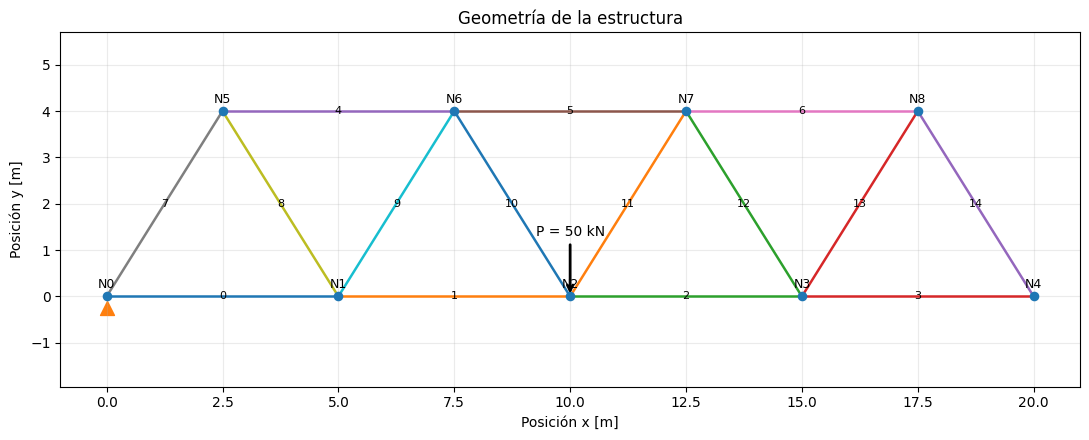

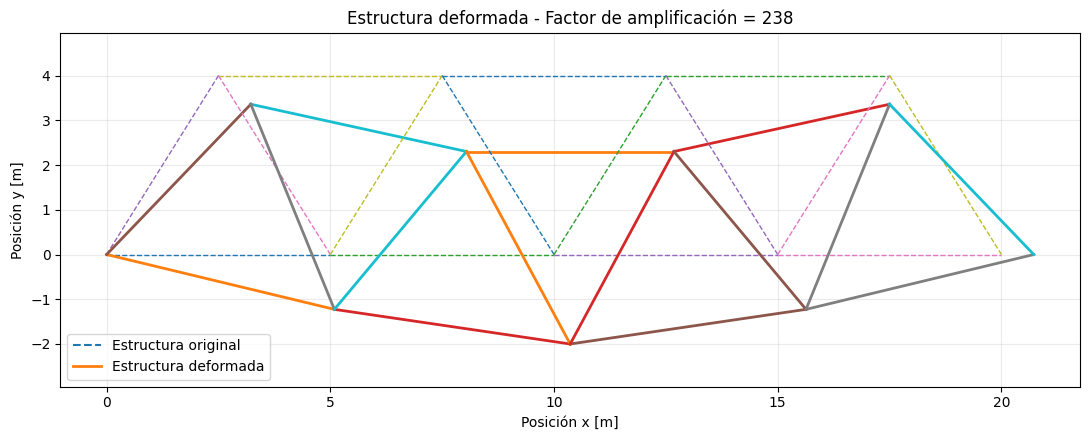

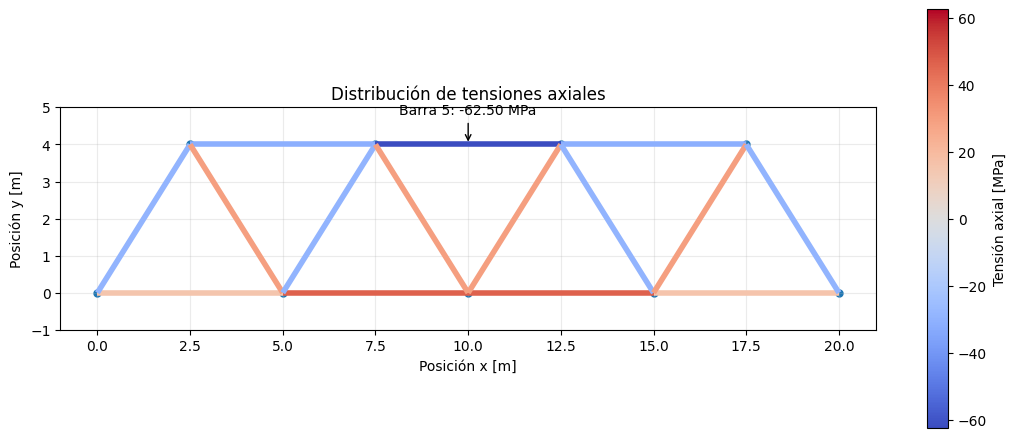

In [16]:
grafico_geometria_2D(
    coordenadas,
    conectividad,
    2,
    0,
    4,
    "diseno_1",
    True
)

grafico_deformada_2D(
    coordenadas,
    conectividad,
    U,
    "diseno_1"
)

grafico_tensiones_2D(
    coordenadas,
    conectividad,
    tensiones,
    "diseno_1"
)

Gráfico Caso 2 2D

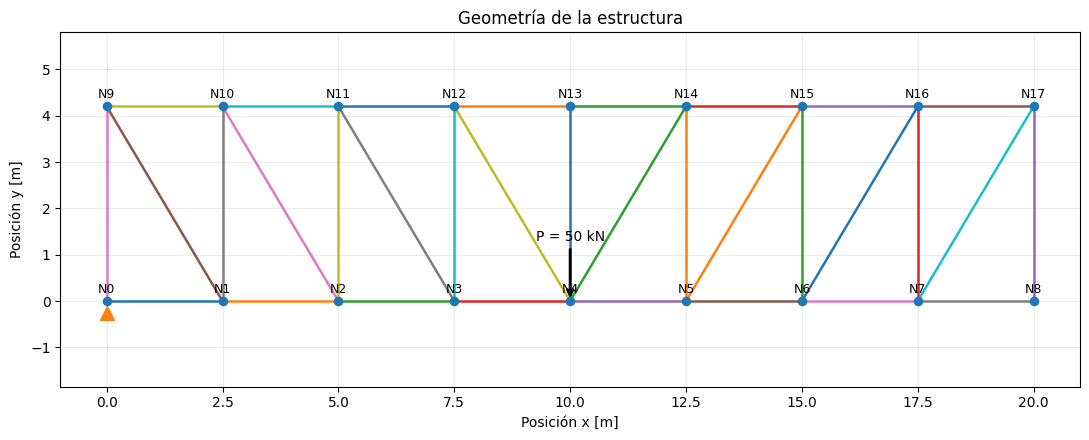

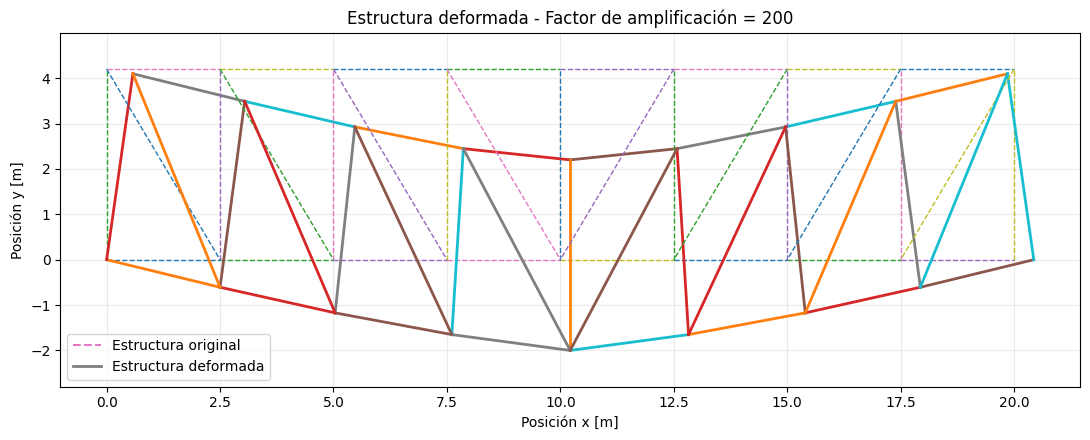

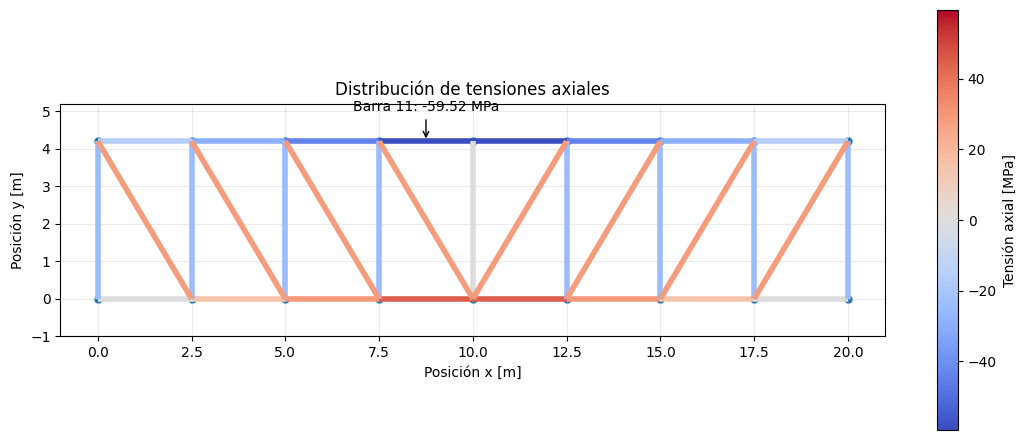

In [17]:
grafico_geometria_2D(
    coordenadas_2,
    conectividad_2,
    4,
    0,
    8,
    "diseno_2",
    False
)

grafico_deformada_2D(
    coordenadas_2,
    conectividad_2,
    U_2,
    "diseno_2"
)

grafico_tensiones_2D(
    coordenadas_2,
    conectividad_2,
    tensiones_2,
    "diseno_2"
)

In [19]:
def grafico_geometria_3D(coordenadas, conectividad, nombre):

    coords = coordenadas / 1000

    fig = plt.figure(figsize=(10, 7))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    for barra in conectividad:

        n1 = barra[0]
        n2 = barra[1]

        ax.plot(
            [coords[n1, 0], coords[n2, 0]],
            [coords[n1, 1], coords[n2, 1]],
            [coords[n1, 2], coords[n2, 2]],
            linewidth=1.5
        )

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        s=25
    )

    for i in range(len(coords)):

        ax.text(
            coords[i, 0],
            coords[i, 1],
            coords[i, 2] + 0.1,
            str(i),
            fontsize=8
        )

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    ax.set_title(
        "Geometría de la estructura tridimensional"
    )

    ax.view_init(
        elev=20,
        azim=-60
    )

    plt.tight_layout()

    plt.savefig(
        f"Graficos/{nombre}_geometria.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def grafico_deformada_3D(coordenadas, conectividad, U, nombre):

    max_u = np.max(np.abs(U))

    escala = 0.1 * (
        np.max(coordenadas[:, 0]) -
        np.min(coordenadas[:, 0])
    ) / max_u

    deformada = coordenadas.copy().astype(float)

    deformada[:, 0] += escala * U[0::3]
    deformada[:, 1] += escala * U[1::3]
    deformada[:, 2] += escala * U[2::3]

    coords = coordenadas / 1000
    coords_def = deformada / 1000

    fig = plt.figure(figsize=(10, 7))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    for barra in conectividad:

        n1 = barra[0]
        n2 = barra[1]

        ax.plot(
            [coords[n1, 0], coords[n2, 0]],
            [coords[n1, 1], coords[n2, 1]],
            [coords[n1, 2], coords[n2, 2]],
            linestyle="--",
            linewidth=1
        )

        ax.plot(
            [coords_def[n1, 0], coords_def[n2, 0]],
            [coords_def[n1, 1], coords_def[n2, 1]],
            [coords_def[n1, 2], coords_def[n2, 2]],
            linewidth=2
        )

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    ax.set_title(
        f"Estructura deformada 3D - Factor = {escala:.0f}"
    )

    ax.view_init(
        elev=20,
        azim=-60
    )

    plt.tight_layout()

    plt.savefig(
        f"Graficos/{nombre}_deformada.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def grafico_tensiones_3D(
    coordenadas,
    conectividad,
    tensiones,
    nombre
):

    coords = coordenadas / 1000

    segmentos = []

    for barra in conectividad:

        n1 = barra[0]
        n2 = barra[1]

        segmentos.append([
            coords[n1],
            coords[n2]
        ])

    limite = np.max(np.abs(tensiones))

    normalizacion = Normalize(
        vmin=-limite,
        vmax=limite
    )

    lineas = Line3DCollection(
        segmentos,
        cmap="coolwarm",
        norm=normalizacion,
        linewidths=3
    )

    lineas.set_array(tensiones)

    fig = plt.figure(figsize=(10, 7))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    ax.add_collection3d(lineas)

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        s=20
    )

    ax.set_xlim(
        np.min(coords[:, 0]),
        np.max(coords[:, 0])
    )

    ax.set_ylim(
        np.min(coords[:, 1]),
        np.max(coords[:, 1])
    )

    ax.set_zlim(
        np.min(coords[:, 2]),
        np.max(coords[:, 2])
    )

    barra_color = fig.colorbar(
        lineas,
        ax=ax,
        shrink=0.7,
        pad=0.1
    )

    barra_color.set_label(
        "Tensión axial [MPa]"
    )

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    ax.set_title(
        "Distribución de tensiones axiales 3D"
    )

    ax.view_init(
        elev=20,
        azim=-60
    )

    plt.tight_layout()

    plt.savefig(
        f"Graficos/{nombre}_tensiones.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Graficos Caso 1 3D

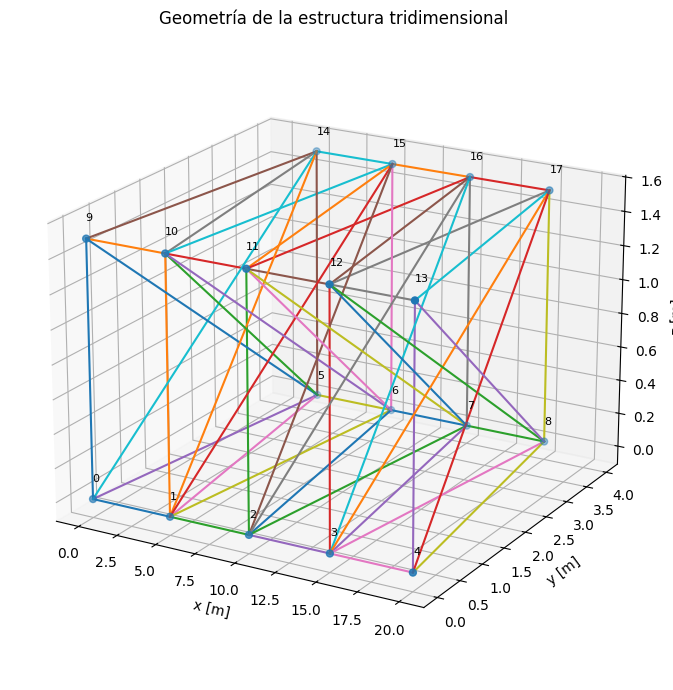

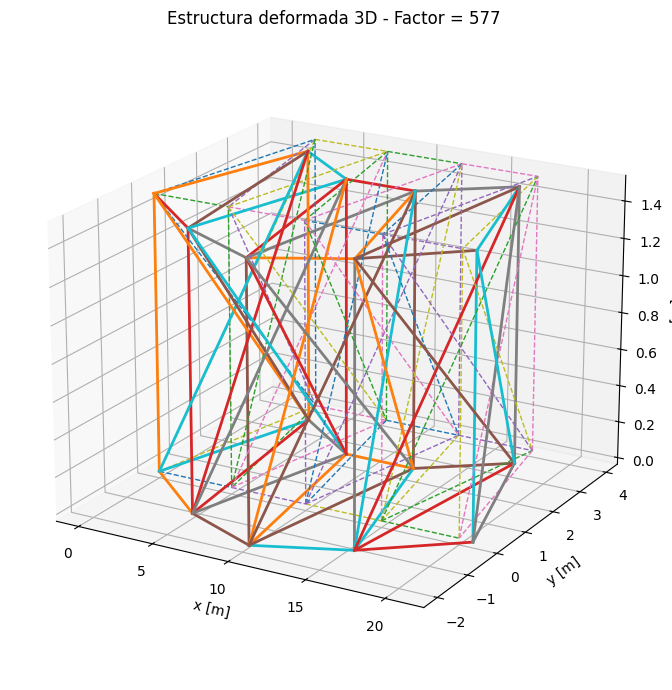

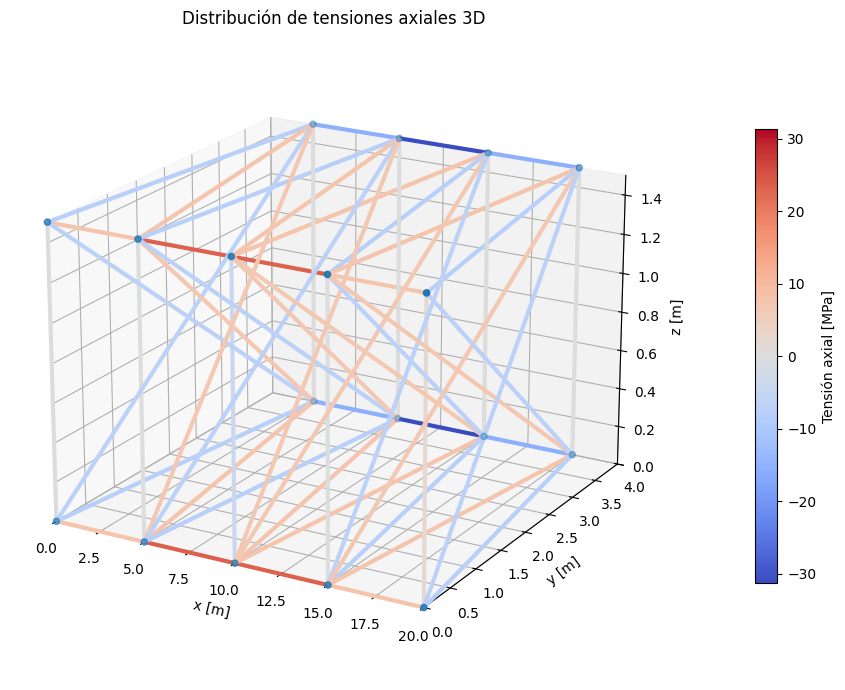

In [20]:
grafico_geometria_3D(
    coordenadas_3D,
    conectividad_3D,
    "diseno_3D"
)

grafico_deformada_3D(
    coordenadas_3D,
    conectividad_3D,
    U_3D,
    "diseno_3D"
)

grafico_tensiones_3D(
    coordenadas_3D,
    conectividad_3D,
    tensiones_3D,
    "diseno_3D"
)